In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
from scipy.optimize import curve_fit 

(20, 10)
                       Mercury  Venus  Earth   Moon   Mars Jupiter  Saturn  \
Attribute                                                                    
Mass (10^24kg)           0.330   4.87   5.97  0.073  0.642    1898     568   
Diameter (km)             4879  12104  12756   3475   6792  142984  120536   
Density (kg/m^3)          5429   5243   5514   3340   3934    1326     687   
Gravity (m/s^2)            3.7    8.9    9.8    1.6    3.7    23.1     9.0   
Escape Velocity (km/s)     4.3   10.4   11.2    2.4    5.0    59.5    35.5   

                       Uranus Neptune   Pluto  
Attribute                                      
Mass (10^24kg)           86.8     102  0.0130  
Diameter (km)           51118   49528    2376  
Density (kg/m^3)         1270    1638    1850  
Gravity (m/s^2)           8.7    11.0     0.7  
Escape Velocity (km/s)   21.3    23.5     1.3  
                        Mercury Venus Earth Moon  Mars  Jupiter   Saturn  \
Attribute                       

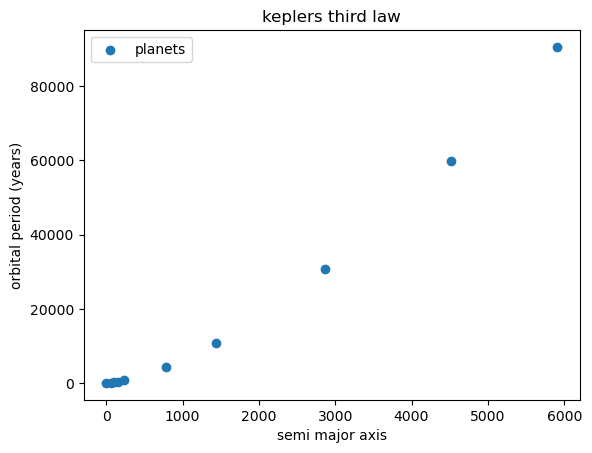

Reduced chi2: 41276.71


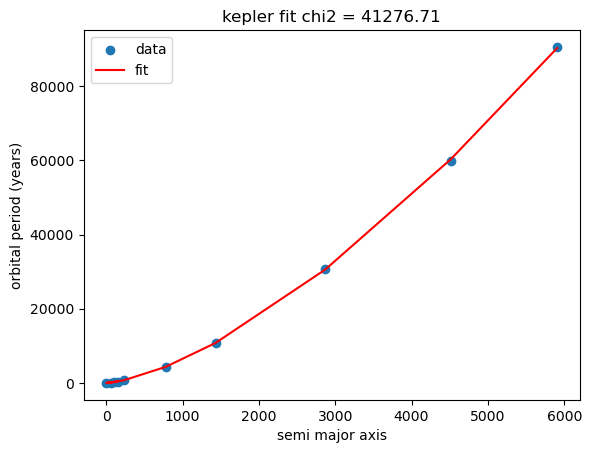

In [15]:
data2 = pd.read_csv('solar_system.csv', index_col =0)
print(data2.shape)
print(data2.head())
print(data2.tail())
print(data2.columns)
print(data2.index)

orbital = data2.loc['Orbital Period (days)'].astype(float)
perihelion = data2.loc['Perihelion (10^6 km)'].astype(float)
aphelion = data2.loc['Aphelion (10^6 km)'].astype(float)

#perihelion is the point in the elliptical orbit thats closest to the sun
#aphelion is the point in the elliptical orbit thats farthest from the sun
#semi-major axis is the distance from the center of orbit to the farthest point of the curve 

semi_major_axis = (perihelion + aphelion)/2
data2.loc['semi-major axis'] = semi_major_axis
print(data2.shape)

plt.scatter(semi_major_axis, orbital, label = 'planets')
plt.xlabel('semi major axis')
plt.ylabel('orbital period (years)')
plt.title('keplers third law')
plt.legend()
plt.show()

residuals = orbital - kepler_model(semi_major_axis, m_fit)
chi2 = np.sum(residuals**2)
bof = len(orbital) - 1
chi2_reduced = chi2 / bof

def kepler_model(a,m):
    return m *a**1.5
popt, _ = curve_fit(kepler_model, semi_major_axis, orbital)
m_fit = popt[0]
print(f'Reduced chi2: {chi2_reduced:.2f}')

plt.scatter(semi_major_axis,orbital, label = 'data')
plt.plot(semi_major_axis, kepler_model(semi_major_axis, m_fit), 'r-', label = 'fit')
plt.title(f'kepler fit chi2 = {chi2_reduced:.2f}')
plt.xlabel('semi major axis')
plt.ylabel('orbital period (years)')
plt.legend()
plt.show()

data2.to_csv('kepler.csv')